In [27]:
# Cell 1: Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

print("Đã import thư viện thành công!")

Đã import thư viện thành công!


In [28]:
# Cell 2: Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Cell 3: Đọc file Cleaned_InSDN_OpenFlow_Dataset.csv
# Đảm bảo đường dẫn này khớp với vị trí file trên Drive của bạn
file_path = '/content/drive/MyDrive/Data_InSDN/Cleaned_InSDN_OpenFlow_Dataset.csv'

print("Đang đọc dữ liệu...")
df = pd.read_csv(file_path)

print(f"Tổng số mẫu: {df.shape[0]}") # Sẽ hiển thị 343889 theo đúng context của bạn
print("Phân bố nhãn Label_Binary:")
print(df['Label_Binary'].value_counts())

Đang đọc dữ liệu...
Tổng số mẫu: 343889
Phân bố nhãn Label_Binary:
Label_Binary
1    275465
0     68424
Name: count, dtype: int64


In [30]:
# Cell 4: Tạo sequence cho từng class độc lập để tránh mất cân bằng
from sklearn.utils import shuffle

features = ['duration', 'packet_count', 'byte_count', 'byte_rate', 'packet_rate', 'Protocol']
target = 'Label_Binary'

# 1. Tách riêng Normal và Anomaly
df_normal = df[df['Label_Binary'] == 0]
df_anomaly = df[df['Label_Binary'] == 1]

X_normal, y_normal = df_normal[features].values, df_normal[target].values
X_anomaly, y_anomaly = df_anomaly[features].values, df_anomaly[target].values

# 2. Hàm tạo sliding window
def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length - 1])
    return np.array(xs), np.array(ys)

seq_length = 10
print("Đang tạo sequence cho từng nhóm dữ liệu...")
X_seq_norm, y_seq_norm = create_sequences(X_normal, y_normal, seq_length)
X_seq_anom, y_seq_anom = create_sequences(X_anomaly, y_anomaly, seq_length)

# 3. Chia 80/20 THEO THỨ TỰ cho từng nhóm
split_norm = int(0.8 * len(X_seq_norm))
split_anom = int(0.8 * len(X_seq_anom))

# Ghép Train
X_train = np.vstack((X_seq_norm[:split_norm], X_seq_anom[:split_anom]))
y_train = np.concatenate((y_seq_norm[:split_norm], y_seq_anom[:split_anom]))

# Ghép Test
X_test = np.vstack((X_seq_norm[split_norm:], X_seq_anom[split_anom:]))
y_test = np.concatenate((y_seq_norm[split_norm:], y_seq_anom[split_anom:]))

# 4. Xáo trộn TẬP HỢP CÁC CHUỖI (Không làm hỏng Time-series bên trong mỗi chuỗi)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

print(f"Kích thước Train: {X_train.shape[0]} mẫu")
print(f"Kích thước Test: {X_test.shape[0]} mẫu")
print(f"Tỉ lệ nhãn trong Test:\n{pd.Series(y_test).value_counts()}")

# 5. Chuyển sang PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

class SDNDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_loader = DataLoader(SDNDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SDNDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print("\nĐã chuẩn bị xong DataLoader hoàn hảo!")

Đang tạo sequence cho từng nhóm dữ liệu...
Kích thước Train: 275095 mẫu
Kích thước Test: 68774 mẫu
Tỉ lệ nhãn trong Test:
1    55091
0    13683
Name: count, dtype: int64

Đã chuẩn bị xong DataLoader hoàn hảo!


In [31]:
# Cell 5: Khai báo class LSTM
class AnomalyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes=1):
        super(AnomalyLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.sigmoid = nn.Sigmoid() # Dùng Sigmoid cho Label_Binary (0 hoặc 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        out = self.sigmoid(out)
        return out

input_size = len(features) # Sẽ là 6
hidden_size = 64
num_layers = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Phần cứng đang sử dụng: {device}")

model = AnomalyLSTM(input_size, hidden_size, num_layers).to(device)

Phần cứng đang sử dụng: cuda


In [32]:
# Cell 6: Compile mô hình
criterion = nn.BCELoss() # Binary Cross Entropy phù hợp cho Label_Binary
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Bắt đầu huấn luyện LSTM...
Epoch [1/15], Loss: 0.0771
Epoch [2/15], Loss: 0.0301
Epoch [3/15], Loss: 0.0224
Epoch [4/15], Loss: 0.0180
Epoch [5/15], Loss: 0.0151
Epoch [6/15], Loss: 0.0120
Epoch [7/15], Loss: 0.0109
Epoch [8/15], Loss: 0.0087
Epoch [9/15], Loss: 0.0075
Epoch [10/15], Loss: 0.0067
Epoch [11/15], Loss: 0.0059
Epoch [12/15], Loss: 0.0053
Epoch [13/15], Loss: 0.0048
Epoch [14/15], Loss: 0.0045
Epoch [15/15], Loss: 0.0041


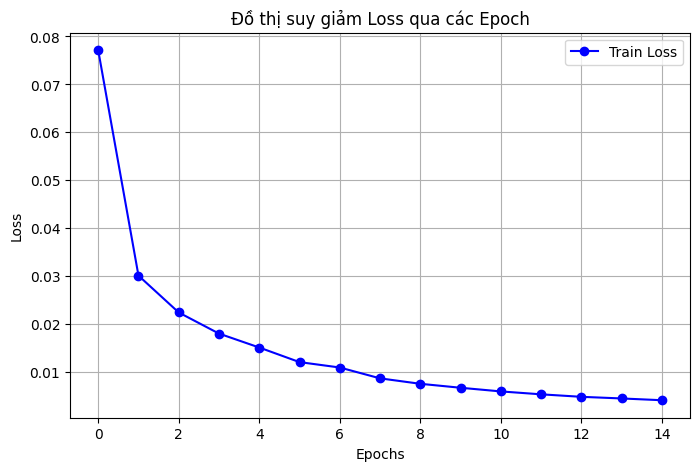

In [33]:
# Cell 7: Huấn luyện
num_epochs = 15
train_losses = []

print("Bắt đầu huấn luyện LSTM...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.title('Đồ thị suy giảm Loss qua các Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [34]:
# Cell 8: Đánh giá trên tập Test
model.eval()
all_preds = []
all_labels = []

print("Đang đánh giá mô hình...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        predicted = (outputs > 0.5).float()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- BÁO CÁO KẾT QUẢ PHÂN LOẠI NHỊ PHÂN ---")
print(classification_report(all_labels, all_preds, target_names=['Normal (0)', 'Anomaly (1)']))

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")

Đang đánh giá mô hình...

--- BÁO CÁO KẾT QUẢ PHÂN LOẠI NHỊ PHÂN ---
              precision    recall  f1-score   support

  Normal (0)       0.94      1.00      0.97     13683
 Anomaly (1)       1.00      0.98      0.99     55091

    accuracy                           0.99     68774
   macro avg       0.97      0.99      0.98     68774
weighted avg       0.99      0.99      0.99     68774

Accuracy : 0.9871
F1-Score : 0.9919


In [35]:
# Cell 9: Lưu model
save_path = '/content/drive/MyDrive/Model_InSDN/sdn_lstm_model.pth'
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình sẵn sàng để deploy tại: {save_path}")

Đã lưu mô hình sẵn sàng để deploy tại: /content/drive/MyDrive/Model_InSDN/sdn_lstm_model.pth
